# Skill Demand: What are the most demanded skills for the top 3 most popular data roles?

## Import Libraries and Data

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Laoding Dataset
df = pd.read_csv(r'C:\Users\ARJUN\Python_projects\Python_Course\data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

## Filter for the United States

In [2]:
df_US = df[df['job_country'] == 'United States'].copy()

## Explode the Skills column

In [3]:
df_US_exploded = df_US.explode('job_skills')

## Skill Counts per Job Role

In [4]:
df_skills_cnt = df_US_exploded.groupby(['job_title_short','job_skills']).size().reset_index(name = 'skill_cnt').sort_values(by = 'skill_cnt', ascending = False)
df_skills_cnt

,job_title_short,job_skills,skill_cnt
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1313,Senior Data Engineer,asp.net core,1
228,Cloud Engineer,ms access,1
1020,Machine Learning Engineer,graphql,1
1582,Senior Data Scientist,mariadb,1


## Top 3 Data Roles

In [5]:
job_roles = sorted(df_skills_cnt['job_title_short'].unique()[0:3].tolist()) # using tolist() owing to the fact unique() is a numpy array
job_roles

['Data Analyst', 'Data Engineer', 'Data Scientist']

## Plot Skill Counts

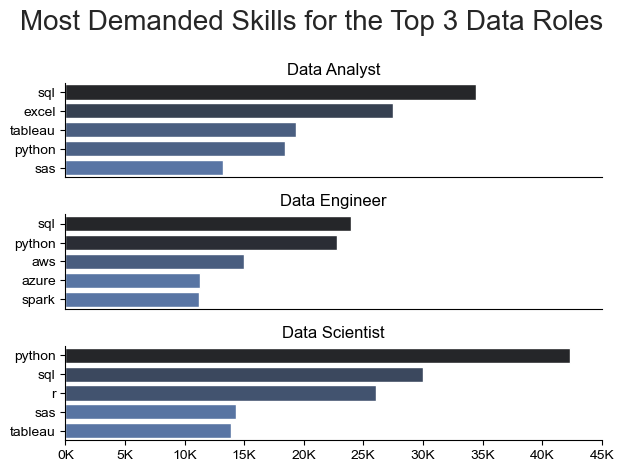

In [6]:
fig, ax = plt.subplots(len(job_roles),1)

sns.set_theme(style = 'ticks')

for i, job in enumerate(job_roles):
    df_plot = df_skills_cnt[df_skills_cnt['job_title_short'] == job].head()

#     df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_cnt', ax = ax[i])
#     ax[i].invert_yaxis()
    
    sns.barplot(data = df_plot, x = 'skill_cnt', y = 'job_skills', ax = ax[i], hue = 'skill_cnt', palette = 'dark:b_r')
    sns.despine()
    ax[i].set_title(job)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,45000)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
    
    if i != len(job_roles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Most Demanded Skills for the Top 3 Data Roles', fontsize = 20)
fig.tight_layout(h_pad = 1.0)
plt.show()

## Convert Counts to Percentages
### Percentage Likelihood of Skill in Job Posting = Total Skill_Cnt / Total Job_Postings

In [7]:
# Job Posting Count by Role
df_job_cnt = df_US['job_title_short'].value_counts().to_frame(name = 'job_cnt')
df_job_cnt

,job_cnt
Data Analyst,67816
Data Scientist,58830
Data Engineer,35080
Senior Data Scientist,12946
Senior Data Analyst,11791
Senior Data Engineer,9289
Business Analyst,7382
Software Engineer,1814
Machine Learning Engineer,921
Cloud Engineer,423


In [8]:
# Merge skill counts with total job counts to calculate skill percentages
df_skills_perc = pd.merge(df_skills_cnt, df_job_cnt, left_on = 'job_title_short', right_on = df_job_cnt.index, how = 'inner')
df_skills_perc['skill_percent'] = 100 * (df_skills_perc['skill_cnt'] / df_skills_perc['job_cnt'])
df_skills_perc

,job_title_short,job_skills,skill_cnt,job_cnt,skill_percent
0,Data Scientist,python,42379,58830,72.036376
1,Data Scientist,sql,30034,58830,51.052184
2,Data Scientist,r,26022,58830,44.232534
3,Data Scientist,sas,14340,58830,24.375319
4,Data Scientist,tableau,13859,58830,23.557709
...,...,...,...,...,...
1865,Cloud Engineer,nltk,1,423,0.236407
1866,Cloud Engineer,no-sql,1,423,0.236407
1867,Cloud Engineer,node.js,1,423,0.236407
1868,Cloud Engineer,mongo,1,423,0.236407


## Plot Percentage Count

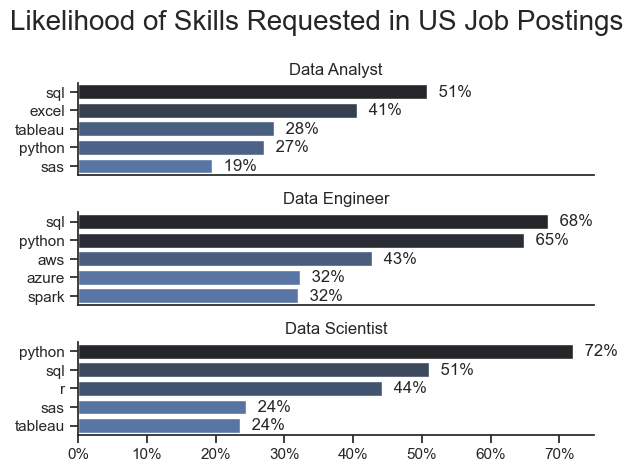

In [9]:
fig, ax = plt.subplots(len(job_roles), 1)

sns.set_theme(style = 'ticks')

for i, job in enumerate(job_roles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job].head()
    sns.barplot(data = df_plot, x = 'skill_percent', y = 'job_skills', ax = ax[i], hue = 'skill_percent', palette = 'dark:b_r')
    sns.despine()
    ax[i].set_title(job)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0,75)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))

    if i != len(job_roles) - 1:
        ax[i].set_xticks([])
        
    for index, value in enumerate(df_plot['skill_percent']):
        ax[i].text(value + 1, index, f'{value: .0f}%', va = 'center')
    
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize = 20)
fig.tight_layout(h_pad = 1.0)
plt.show()